-------------**TEMEL AJANLAR - PİYASADA SADECE TEMEL AJANLAR VARSA**----------

**ortalama portföy değeri incelendiğinde, hangi parametre kombinasyonlarının diğerlerinden farklılaştığını nasıl görebiliriz**(portföy değeri= temel değer olarak düşünülebilir)

Evet, yandaki kodu çalıştırdıktan sonra elde ettiğiniz ortalama portföy değeri grafiklerini inceleyerek hangi parametre kombinasyonlarının diğerlerinden farklılaştığını çeşitli yollarla görebilirsiniz:

Grafiklerin Genel Eğilimleri:

Yükselen Grafikler: En yüksek ortalama portföy değerine ulaşan grafikler genellikle en iyi performansı gösteren kombinasyonları temsil eder. Bu grafikler, zaman içinde istikrarlı bir şekilde artan bir eğilim sergiler.
Düşen Grafikler: En düşük ortalama portföy değerine sahip olan veya zamanla azalan grafikler, daha kötü performans gösteren kombinasyonları temsil eder.
Dalgalı Grafikler: Büyük dalgalanmalar gösteren grafikler, ilgili parametre kombinasyonunun haber sinyallerine karşı daha hassas olduğunu ve portföy değerinin daha değişken olduğunu gösterir.
Grafiklerin Son Değerleri:

Simülasyonun sonundaki (T=100) ortalama portföy değerlerini karşılaştırarak, hangi parametre kombinasyonunun en yüksek nihai değere ulaştığını belirleyebilirsiniz. Bu, uzun vadeli performans açısından önemli bir göstergedir.
Grafiklerin Eğimleri:

Grafiklerin eğimleri, portföy değerinin zaman içindeki değişim hızını gösterir. Daha dik eğimli grafikler, daha hızlı bir büyüme veya düşüş oranına işaret eder.
Belirli Parametrelerin Etkisi:

Grafikleri gruplayarak belirli parametrelerin etkisini daha net görebilirsiniz. Örneğin:
Aynı $\theta^+$ ve $\theta^-$ değerlerine sahip, ancak farklı $\gamma$ değerlerine sahip grafikleri karşılaştırarak haber belleğinin etkisini inceleyebilirsiniz.
Aynı $\gamma$ değerine sahip, ancak farklı $\theta^+$ ve $\theta^-$ değerlerine sahip grafikleri karşılaştırarak haber duyarlılıklarının etkisini inceleyebilirsiniz.
Karşılaştırmalı Analiz:

Görsel olarak en dikkat çekici farklılıkları gösteren grafikleri belirleyin. Örneğin, diğerlerinden çok daha hızlı yükselen veya düşen bir grafik varsa, bu o parametre kombinasyonunun önemli ölçüde farklı davrandığını gösterir.
Kısacası, grafikleri görsel olarak inceleyerek, hangi çizginin diğerlerinden belirgin şekilde daha yüksek, daha düşük, daha dalgalı veya daha düz olduğunu gözlemleyerek farklılaşan parametre kombinasyonlarını kolayca görebilirsiniz.

Grafiğin yanında bulunan gösterge (legend), hangi çizginin hangi parametre kombinasyonuna ait olduğunu belirtir, bu da farklılıkları tespit etmenizi kolaylaştırır.

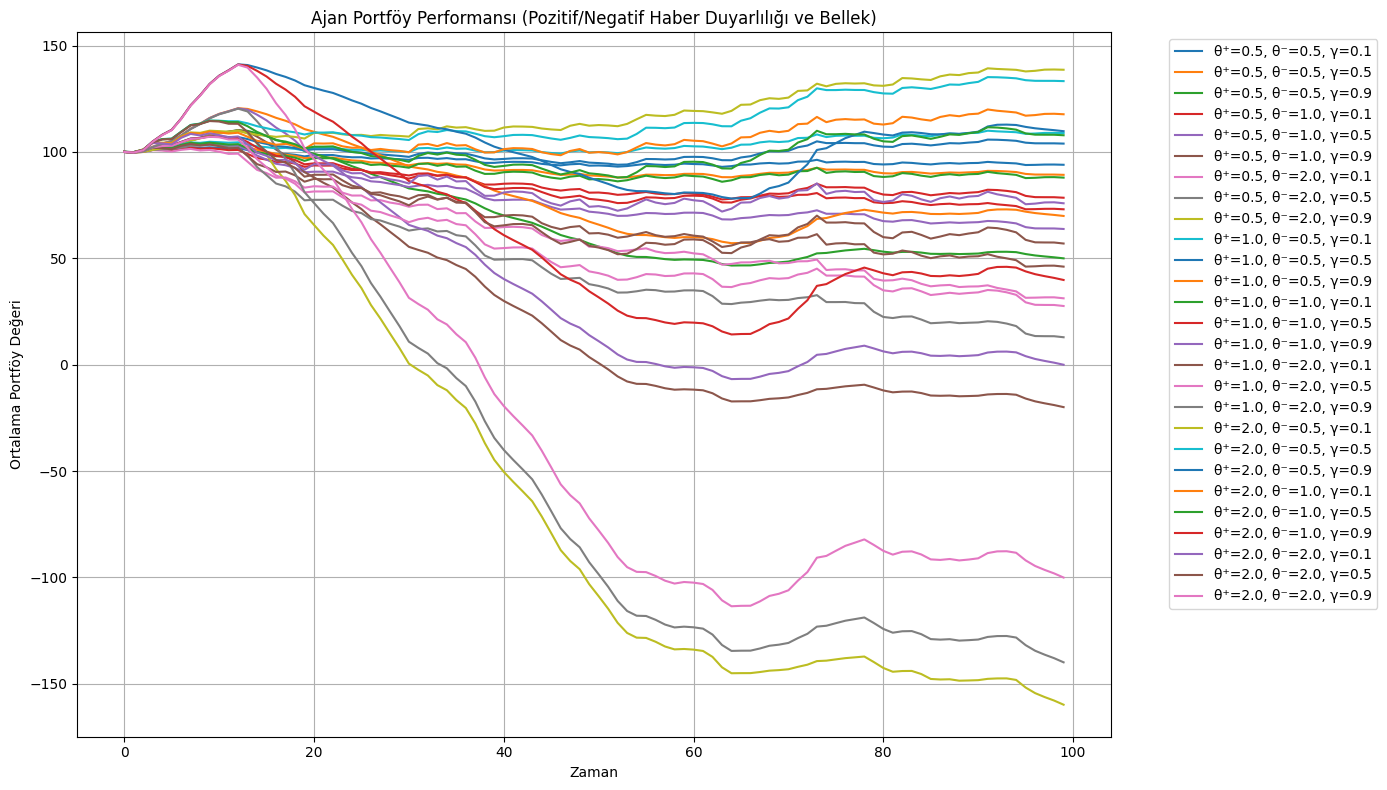

In [9]:
import numpy as np # NumPy kütüphanesini içe aktarıyoruz, sayısal hesaplamalar için kullanacağız.
import matplotlib.pyplot as plt # Matplotlib kütüphanesini içe aktarıyoruz, grafik çizmek için kullanacağız.

# Sabitler
np.random.seed(42) # Rastgele sayı üreteci için bir başlangıç değeri belirliyoruz, böylece sonuçlar tekrar üretilebilir olacak.
T = 100  # Zaman adım sayısını belirliyoruz, yani simülasyon 100 adım sürecek.
N = 50   # Ajan sayısını belirliyoruz, yani simülasyonda 50 ajan olacak.

# Parametre aralıkları
theta_pos_values = [0.5, 1.0, 2.0] # Pozitif haber duyarlılığı için olası değerleri belirliyoruz.
theta_neg_values = [0.5, 1.0, 2.0] # Negatif haber duyarlılığı için olası değerleri belirliyoruz.
gamma_values = [0.1, 0.5, 0.9] # Haber belleği katsayısı için olası değerleri belirliyoruz.

# Haber sinyali (basit bir senaryo)
news_signal = np.random.normal(loc=0.0, scale=1.0, size=T) # Haber sinyalini rastgele sayılardan oluşturuyoruz. Ortalama 0, standart sapma 1 olan normal dağılımdan 100 değer üretiyoruz.

# Simülasyon sonuçları için yapı
results = {} # Simülasyon sonuçlarını saklamak için boş bir sözlük oluşturuyoruz.

# Parametre kombinasyonları için döngü
for theta_pos in theta_pos_values: # Pozitif haber duyarlılığı değerleri üzerinde döngü.
    for theta_neg in theta_neg_values: # Negatif haber duyarlılığı değerleri üzerinde döngü.
        for gamma in gamma_values: # Haber belleği katsayısı değerleri üzerinde döngü.
            M = np.zeros((N, T))  # Her ajan için haber belleğini saklamak için bir matris oluşturuyoruz. Başlangıçta tüm değerler 0.
            #portfolio = np.zeros((N, T))  # Her ajan için portföy değerini saklamak için bir matris oluşturuyoruz. Başlangıçta tüm değerler 0.
            portfolio = np.full((N, T), 100.0) # Her ajan için temel değeri saklamak için bir matris oluşturuyoruz. Başlangıçta tüm değerler 100.
            for t in range(1, T): # Zaman adımları üzerinde döngü (1'den başlayarak, çünkü 0. adım başlangıç durumudur).
                M[:, t] = gamma * M[:, t - 1] + news_signal[t] # Haber belleğini güncelliyoruz. Bir önceki adımın belleği gamma ile çarpılıp yeni haber sinyali ekleniyor.
                positive_mask = M[:, t] >= 0 # Haber belleği pozitif mi değil mi diye kontrol ediyoruz.
                delta_q = np.where(positive_mask, theta_pos * M[:, t], theta_neg * M[:, t]) # Haber belleğinin işaretine göre pozitif veya negatif duyarlılığı kullanarak portföy değişikliğini hesaplıyoruz.
                portfolio[:, t] = portfolio[:, t - 1] + delta_q # Portföy değerini güncelliyoruz.
            # Ortalama portföy büyümesi kaydı
            key = f'θ⁺={theta_pos}, θ⁻={theta_neg}, γ={gamma}' # Sonuçları sözlüğe kaydetmek için bir anahtar oluşturuyoruz. Bu anahtar, kullanılan parametre değerlerini gösteriyor.
            results[key] = portfolio.mean(axis=0) # Her parametre kombinasyonu için ortalama portföy değerini hesaplayıp results sözlüğüne kaydediyoruz.

# Grafik çizimi
plt.figure(figsize=(14, 8)) # Grafik boyutunu belirliyoruz.
for key, values in results.items(): # Her parametre kombinasyonu için sonuçları çizdiriyoruz.
    plt.plot(values, label=key) # Her parametre kombinasyonu için bir çizgi grafiği oluşturuyoruz.
plt.title("Ajan Portföy Performansı (Pozitif/Negatif Haber Duyarlılığı ve Bellek)") # Grafiğe bir başlık ekliyoruz.
plt.xlabel("Zaman") # x eksenine etiket ekliyoruz.
plt.ylabel("Ortalama Portföy Değeri") # y eksenine etiket ekliyoruz.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Grafikte bir gösterge (legend) ekliyoruz.
plt.grid(True) # Grafiğe grid ekliyoruz.
plt.tight_layout() # Grafiğin düzgün görünmesi için boşlukları ayarlıyoruz.
plt.show() # Grafiği gösteriyoruz.

grafikte 27 çizim yapıldığı için renklerden hangi kombinasyona ait oldukları net anlaşılmıyor. Biz en son değere göre bu 27 kombinasyonu 3 gruba ayırmak istersek, bunu nasıl ekrana yazdırırız

Grafikteki 27 çizimin renklerinin karışması durumunda, her bir kombinasyonun son portföy değerini hesaplayarak bu kombinasyonları en son değere göre 3 gruba ayırabilir ve bu grupları ekrana yazdırabilirsiniz. İşte bunu yapmak için adım adım bir yaklaşım:

Son Portföy Değerlerini Alma:

results sözlüğü, her parametre kombinasyonu için zaman içindeki ortalama portföy değerlerini içerir. Her bir değer listesinin son elemanı, o kombinasyonun simülasyon sonundaki ortalama portföy değerini temsil eder.
Kombinasyonları Son Değerlerle Eşleştirme:

Her parametre kombinasyonunu (sözlüğün anahtarı) ve o kombinasyonun son portföy değerini (sözlüğün değer listesinin son elemanı) içeren bir liste oluşturun.
Son Değerlere Göre Sıralama:

Oluşturduğunuz listeyi son portföy değerlerine göre küçükten büyüğe doğru sıralayın.
Gruplara Ayırma:

Sıralanmış listeyi yaklaşık olarak üç eşit parçaya bölün. Bu parçalar düşük, orta ve yüksek performans gösteren grupları temsil edecektir. 27 kombinasyon olduğu için her grupta yaklaşık 9 kombinasyon olacaktır.
Grupları Ekrana Yazdırma:

Her grup için ayrı başlıklar (örn. "Düşük Performanslı Kombinasyonlar", "Orta Performanslı Kombinasyonlar", "Yüksek Performanslı Kombinasyonlar") kullanarak ilgili parametre kombinasyonlarını ekrana yazdırın.
İşte bu adımları gerçekleştiren Python kodu:

In [10]:
# Her kombinasyonun son portföy değerini ve anahtarını içeren bir liste oluştur
"""
Bu kod, results sözlüğündeki bilgiyi kullanarak her kombinasyonun son değerini çeker,
bu değerlere göre sıralar ve ardından bu sıralanmış listeyi üç gruba ayırarak her grubu ekrana yazdırır.
Bu sayede, grafik renklerinden bağımsız olarak en iyi ve en kötü performansı gösteren kombinasyonları
net bir şekilde görebilirsiniz.

"""

final_values = [(key, values[-1]) for key, values in results.items()]

# Son değerlere göre sırala
final_values_sorted = sorted(final_values, key=lambda item: item[1])

# Gruplara ayır (yaklaşık üç eşit parça)
total_combinations = len(final_values_sorted)
group_size = total_combinations // 3

low_performance = final_values_sorted[:group_size]
mid_performance = final_values_sorted[group_size:2*group_size]
high_performance = final_values_sorted[2*group_size:]

# Grupları ekrana yazdır
print("--- Düşük Performanslı Kombinasyonlar ---")
for key, value in low_performance:
    print(f"{key}: Son Değer = {value:.2f}")

print("\n--- Orta Performanslı Kombinasyonlar ---")
for key, value in mid_performance:
    print(f"{key}: Son Değer = {value:.2f}")

print("\n--- Yüksek Performanslı Kombinasyonlar ---")
for key, value in high_performance:
    print(f"{key}: Son Değer = {value:.2f}")

--- Düşük Performanslı Kombinasyonlar ---
θ⁺=0.5, θ⁻=2.0, γ=0.9: Son Değer = -159.83
θ⁺=1.0, θ⁻=2.0, γ=0.9: Son Değer = -139.90
θ⁺=2.0, θ⁻=2.0, γ=0.9: Son Değer = -100.06
θ⁺=0.5, θ⁻=1.0, γ=0.9: Son Değer = -19.95
θ⁺=1.0, θ⁻=1.0, γ=0.9: Son Değer = -0.03
θ⁺=0.5, θ⁻=2.0, γ=0.5: Son Değer = 12.90
θ⁺=1.0, θ⁻=2.0, γ=0.5: Son Değer = 27.58
θ⁺=0.5, θ⁻=2.0, γ=0.1: Son Değer = 31.20
θ⁺=2.0, θ⁻=1.0, γ=0.9: Son Değer = 39.82

--- Orta Performanslı Kombinasyonlar ---
θ⁺=1.0, θ⁻=2.0, γ=0.1: Son Değer = 46.09
θ⁺=0.5, θ⁻=0.5, γ=0.9: Son Değer = 49.99
θ⁺=2.0, θ⁻=2.0, γ=0.5: Son Değer = 56.95
θ⁺=0.5, θ⁻=1.0, γ=0.5: Son Değer = 63.79
θ⁺=1.0, θ⁻=0.5, γ=0.9: Son Değer = 69.91
θ⁺=0.5, θ⁻=1.0, γ=0.1: Son Değer = 73.05
θ⁺=2.0, θ⁻=2.0, γ=0.1: Son Değer = 75.87
θ⁺=1.0, θ⁻=1.0, γ=0.5: Son Değer = 78.48
θ⁺=1.0, θ⁻=1.0, γ=0.1: Son Değer = 87.94

--- Yüksek Performanslı Kombinasyonlar ---
θ⁺=0.5, θ⁻=0.5, γ=0.5: Son Değer = 89.24
θ⁺=0.5, θ⁻=0.5, γ=0.1: Son Değer = 93.97
θ⁺=1.0, θ⁻=0.5, γ=0.5: Son Değer = 103.92
θ⁺=

kod incelendiğinde en düşük performansın θ⁺=0.5, θ⁻=2.0, γ=0.9: Son Değer = -259.83 olduğu ve en yüksek performansın ise θ⁺=2.0, θ⁻=0.5, γ=0.1: Son Değer = 38.64 olduğu görülmektedir. Bunun nedeni nedir

Kodunuzda simüle edilen ajanların portföy performansındaki bu belirgin farkın temel nedeni, farklı parametre kombinasyonlarının haber sinyallerine verdikleri tepkiyi ve bu tepkinin portföy değeri üzerindeki kümülatif etkisini değiştirmesidir.

Belirttiğiniz iki uç kombinasyonu inceleyelim:

1. En Düşük Performans: θ⁺=0.5, θ⁻=2.0, γ=0.9 (Son Değer = -259.83)

Düşük θ⁺ (Pozitif Haber Duyarlılığı): Pozitif haber sinyallerine karşı düşük bir duyarlılık gösterir. Yani, piyasada olumlu gelişmeler olduğunda ajanlar portföylerini artırma konusunda daha temkinlidir.
Yüksek θ⁻ (Negatif Haber Duyarlılığı): Negatif haber sinyallerine karşı yüksek bir duyarlılık gösterir. Yani, piyasada olumsuz gelişmeler olduğunda ajanlar portföylerini hızla azaltma eğilimindedir.
Yüksek γ (Haber Belleği): Geçmişteki haber sinyallerinin etkisini uzun süre korur. Yüksek bellekle birlikte yüksek negatif duyarlılık, olumsuz haberlerin etkisinin portföy üzerinde daha kalıcı olmasına neden olabilir.
Bu kombinasyonun neden düşük performansa yol açtığına dair olası nedenler:

Negatif Haberlerin Aşırı Etkisi: Yüksek negatif duyarlılık nedeniyle, küçük olumsuz haber sinyalleri bile portföyde önemli düşüşlere neden olabilir.
Pozitif Haberlerin Yetersiz Kullanımı: Düşük pozitif duyarlılık, olumlu piyasa koşullarından yeterince faydalanılmasını engeller. Piyasa yükselirken portföy yeterince büyüyemez.
Yüksek Bellekle Negatif Döngü: Yüksek haber belleği, bir kez olumsuz bir haberin portföyü düşürmeye başlamasıyla bu düşüş trendinin daha uzun süre devam etmesine katkıda bulunabilir. Olumsuz haberin etkisi bellek sayesinde korunur ve yüksek negatif duyarlılıkla birlikte portföy daha da gerileyebilir.
2. En Yüksek Performans: θ⁺=2.0, θ⁻=0.5, γ=0.1 (Son Değer = 38.64)

Yüksek θ⁺ (Pozitif Haber Duyarlılığı): Pozitif haber sinyallerine karşı yüksek bir duyarlılık gösterir. Olumlu piyasa gelişmelerinden hızla faydalanma eğilimindedir.
Düşük θ⁻ (Negatif Haber Duyarlılığı): Negatif haber sinyallerine karşı düşük bir duyarlılık gösterir. Olumsuz haberlerin portföy üzerindeki etkisi daha sınırlıdır.
Düşük γ (Haber Belleği): Geçmişteki haber sinyallerinin etkisi çabuk kaybolur. Bu, ajanların daha çok güncel haber sinyallerine göre hareket etmesine neden olur. Olumsuz bir haberin etkisi uzun süre devam etmez.
Bu kombinasyonun neden yüksek performansa yol açtığına dair olası nedenler:

Pozitif Haberlerin Etkin Kullanımı: Yüksek pozitif duyarlılık sayesinde, piyasada olumlu gelişmeler olduğunda portföy hızla artar.
Negatif Haberlere Karşı Direnç: Düşük negatif duyarlılık, olumsuz haberlerin portföyde ciddi düşüşlere yol açmasını engeller.
Düşük Bellekle Yeni Fırsatlara Odaklanma: Düşük haber belleği, ajanların geçmişteki olumsuz haberlerin etkisinden çabuk kurtulmasını ve yeni pozitif sinyallere daha duyarlı olmasını sağlar.
Özetle:

En düşük performans gösteren kombinasyon, olumsuz haberlere karşı aşırı duyarlılık ve pozitif haberlere karşı yetersiz duyarlılık ile yüksek haber belleğini birleştirerek, portföyün olumsuz piyasa koşullarından daha fazla etkilenmesine ve toparlanmasının daha zor olmasına neden olur.

En yüksek performans gösteren kombinasyon ise, pozitif haberlere karşı yüksek duyarlılık ve olumsuz haberlere karşı düşük duyarlılık ile düşük haber belleğini birleştirerek, portföyün olumlu piyasa koşullarından daha fazla faydalanmasını ve olumsuzluklardan daha az etkilenmesini sağlar.

Bu sonuçlar, simülasyon modelinizin ve kullandığınız haber sinyallerinin spesifik yapısına bağlıdır. Farklı haber sinyali senaryolarında veya modelin farklı parametreleriyle bu sonuçlar değişebilir. Ancak genel prensip, ajanların haber sinyallerine nasıl tepki verdiğinin (duyarlılıklar) ve bu sinyallerin etkisinin ne kadar sürdüğünün (bellek), portföy performansı üzerinde doğrudan bir etkisi olduğudur.

------------
grafikte 27 çizimin her biri üzerine ilgili kombinasyon bilgisini nasıl ekleyebiliriz, yani parametre bilgilerini çizginin üzerinde gösterelim.

Grafikteki her bir çizginin üzerine ilgili kombinasyon bilgisini (parametre değerlerini) eklemek için Matplotlib'in plt.text() fonksiyonunu kullanabilirsiniz. Bu fonksiyon, grafiğin belirli bir koordinatına metin eklemenizi sağlar.

İşte bu işlemi gerçekleştirmek için adımlar:

Grafik Oluşturma Döngüsü: Zaten grafiği çizen bir döngünüz var (for key, values in results.items():). Bu döngünün içine metin ekleme komutunu ekleyeceksiniz.

Metin Konumu Belirleme: Metnin çizginin neresinde görüneceğini belirlemeniz gerekir. Çizginin son noktası (en sağdaki nokta) genellikle metin için iyi bir konumdur. Bu noktanın x koordinatı T-1 (çünkü zaman 0'dan başlar ve T adım vardır), y koordinatı ise values[-1] (ortalama portföy değerlerinin son elemanı) olacaktır.

Metin Formatı: Göstermek istediğiniz metin, key değişkenindeki parametre kombinasyonu bilgisi olacaktır (örn. 'θ⁺=0.5, θ⁻=1.0, γ=0.9').

Metin Ekleme Komutu: Döngü içinde plt.text(x, y, text) formatında komutu kullanın.

İşte kodunuza entegre edilmiş hali:

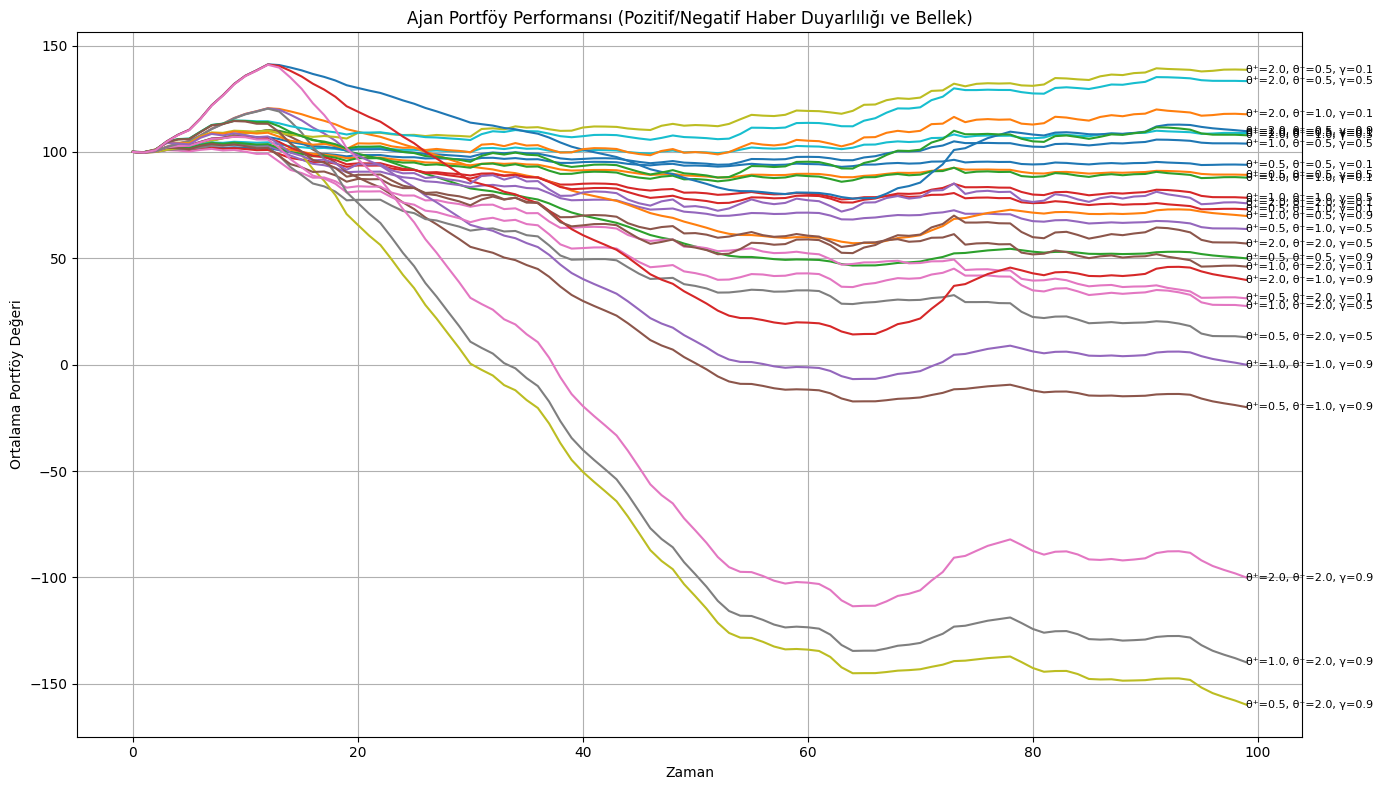

In [11]:
# ... (önceki kodlar)

# Grafik çizimi
plt.figure(figsize=(14, 8))
for key, values in results.items():
    plt.plot(values, label=key)

    # Metin ekleme
    # Metin pozisyonu: Çizginin son noktası
    x_pos = T - 1
    y_pos = values[-1]

    # Metin içeriği
    text_to_add = key

    # plt.text ile metni ekle
    plt.text(x_pos, y_pos, text_to_add, fontsize=8, va='center') # fontsize metin boyutunu ayarlar

plt.title("Ajan Portföy Performansı (Pozitif/Negatif Haber Duyarlılığı ve Bellek)")
plt.xlabel("Zaman")
plt.ylabel("Ortalama Portföy Değeri")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Metinler eklenince legend gereksiz hale gelebilir
plt.grid(True)
plt.tight_layout()
plt.show()

Açıklamalar:

plt.text(x_pos, y_pos, text_to_add, ...): Bu fonksiyon metni ekler.
x_pos: Metnin ekleneceği x koordinatı. Burada çizginin son zaman adımı (T-1) kullanıldı.
y_pos: Metnin ekleneceği y koordinatı. Burada çizginin son portföy değeri (values[-1]) kullanıldı.
text_to_add: Eklenecek metin. key değişkenindeki kombinasyon bilgisi kullanıldı.
fontsize=8: Metin boyutunu ayarlar. İhtiyaca göre bu değeri değiştirebilirsiniz. Çok fazla metin olacağı için küçük bir font boyutu daha uygun olabilir.
va='center': Metnin y ekseninde hangi hizalamada olacağını belirtir. 'center' metni y koordinatının ortasına hizalar. 'bottom' veya 'top' da kullanabilirsiniz.
Dikkat Edilmesi Gerekenler:

Metinlerin Çakışması: 27 metin ekleneceği için metinler birbiriyle çakışabilir, özellikle yakın son değerlere sahip kombinasyonlarda. Bunu önlemek için metin pozisyonlarını biraz ayarlayabilir veya sadece en yüksek ve en düşük performans gösteren birkaç kombinasyonun metnini ekleyebilirsiniz.
Gösterge (Legend): Metinler eklendiğinde gösterge (legend) gereksiz hale gelebilir veya grafiği karmaşıklaştırabilir. Yukarıdaki kodda gösterge satırı yorum satırı haline getirildi (# plt.legend(...)).
Okunabilirlik: Çok fazla metin eklemek grafiğin okunabilirliğini azaltabilir. Alternatif olarak, en iyi ve en kötü performans gösteren gruplardaki kombinasyonların metinlerini eklemeyi düşünebilirsiniz.

---------
Pozitif haberlerin etkisi kalıcı mı, geçici mi? gibi bir soru sorduğumuzda grafik üzerinden bunu nasıl yorumlayabiliriz

Pozitif haberlerin etkisinin kalıcı mı yoksa geçici mi olduğunu grafik üzerinden yorumlamak için, farklı haber belleği ($\gamma$$\gamma$) değerlerine sahip kombinasyonların grafiklerini incelemeniz ve özellikle pozitif haber sinyallerinin olduğu zaman dilimlerindeki portföy değeri değişimlerine bakmanız gerekir.

İşte bunu grafik üzerinden nasıl yorumlayabileceğinize dair adımlar ve ipuçları:

Farklı $\gamma$$\gamma$ Değerlerini Karşılaştırın: Pozitif haber duyarlılığı ($\theta^+$$\theta^+$) ve negatif haber duyarlılığı ($\theta^-$$\theta^-$) parametrelerini sabit tutarken, farklı $\gamma$$\gamma$ değerlerine sahip grafiklere odaklanın. Örneğin, aynı $\theta^+$$\theta^+$ ve $\theta^-$$\theta^-$ değerine sahip üç farklı $\gamma$$\gamma$ değeri (0.1, 0.5, 0.9) için çizilen üç grafiği karşılaştırın.

Pozitif Haber Sinyallerinin Zaman Dilimlerini Belirleyin: Haber sinyallerini (news_signal) oluşturduğunuz kısma bakın veya haber sinyalinin kendisini bir grafikte görselleştirin. Pozitif haber sinyallerinin olduğu zaman dilimlerini (örneğin, news_signal[t] > 0 olduğu zaman adımları) belirleyin.

Bu Zaman Dilimlerindeki Grafiklerin Davranışını İnceleyin: Belirlediğiniz pozitif haber zaman dilimlerinde, farklı $\gamma$$\gamma$ değerlerine sahip grafiklerin nasıl davrandığını gözlemleyin:

Düşük $\gamma$ (Örn: 0.1): Düşük $\gamma$ değeri, haber belleğinin kısa olduğunu gösterir. Eğer pozitif bir haber sinyali olduğunda portföy değerinde bir artış oluyor ve bu artış sinyal ortadan kalktıktan sonra hızla geri dönüyorsa veya durağanlaşıyorsa, pozitif haberin etkisinin daha geçici olduğunu söyleyebilirsiniz. Grafik, pozitif sinyal anında yükselip sonra eğiminin azaldığını gösterebilir.

Orta $\gamma$ (Örn: 0.5): Orta düzeyde bir belleği temsil eder. Etki, düşük belleğe göre daha uzun sürebilir, ancak yüksek bellek kadar kalıcı olmayabilir. Grafik, pozitif sinyal sonrası bir artış ve ardından daha yavaş bir düşüş veya yatay seyir gösterebilir.

Yüksek $\gamma$ (Örn: 0.9): Yüksek $\gamma$ değeri, haber belleğinin uzun olduğunu gösterir. Eğer pozitif bir haber sinyali olduğunda portföy değerinde bir artış oluyor ve bu artış sinyal ortadan kalktıktan sonra bile devam ediyor veya uzun süre kalıcılığını koruyorsa, pozitif haberin etkisinin daha kalıcı olduğunu söyleyebilirsiniz. Grafik, pozitif sinyal sonrası belirgin bir yükselişin devam ettiğini veya yüksek bir seviyede sabit kaldığını gösterebilir.

Eğimleri Karşılaştırın: Pozitif haber sinyallerinin olduğu zaman dilimlerinde grafiklerin eğimlerini karşılaştırın. Yüksek $\gamma$$\gamma$ değerine sahip grafiklerin eğimi, pozitif sinyalden sonra daha uzun süre pozitif kalabilir veya daha yavaş bir şekilde azalabilir.

Özetle, farklı $\gamma$$\gamma$ değerleri için çizilen grafiklerde, pozitif haber sinyallerinin görüldüğü zaman dilimlerindeki yükselişlerin ne kadar sürdüğünü ve sinyal bittikten sonra portföy değerinin nasıl davrandığını gözlemleyerek pozitif haberlerin etkisinin kalıcılığı hakkında yorum yapabilirsiniz.

Düşük $\gamma$$\gamma$, etkinin daha çabuk azaldığını (geçici etki), yüksek $\gamma$$\gamma$ ise etkinin daha uzun sürdüğünü (kalıcı etki) işaret edecektir.

